# Лабораторная работа №3 «Понижение размерности»

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.metrics import mean_squared_error

df = pd.read_csv('../date/BostonHousing.csv')
print()
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')


Размер датасета: 506 строк, 14 столбцов


In [2]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


- `CRIM` - Уровень преступности на душу населения
- `ZN` - Доля земель под жильё с участками >25 тыс. кв.футов
- `INDUS` - Доля промышленных земель
- `CHAS` - Граничит ли район с рекой Чарльз (1/0)
- `NOX` - Концентрация оксидов азота (загрязнение)
- `RM` - Среднее число комнат в доме
- `AGE` - Доля домов, построенных до 1940 года
- `DIS` - Расстояние до центров занятости
- `RAD` - Индекс доступности к автомагистралям
- `TAX` - Ставка налога на недвижимость
- `PTRATIO` - Соотношение ученик/учитель в школах
- `B` - 1000(Bk − 0.63)², где Bk — доля афроамериканцев
- `LSTAT` - % населения с низким статусом
- `MEDV` - Медианная стоимость дома ($1000)

## Задание 1. Геометрия данных в пространстве признаков

In [3]:
X = df.drop('medv', axis=1)
print(f"Число объектов (строк): {X.shape[0]}")
print(f"Число признаков (столбцов): {X.shape[1]}")

Число объектов (строк): 506
Число признаков (столбцов): 13


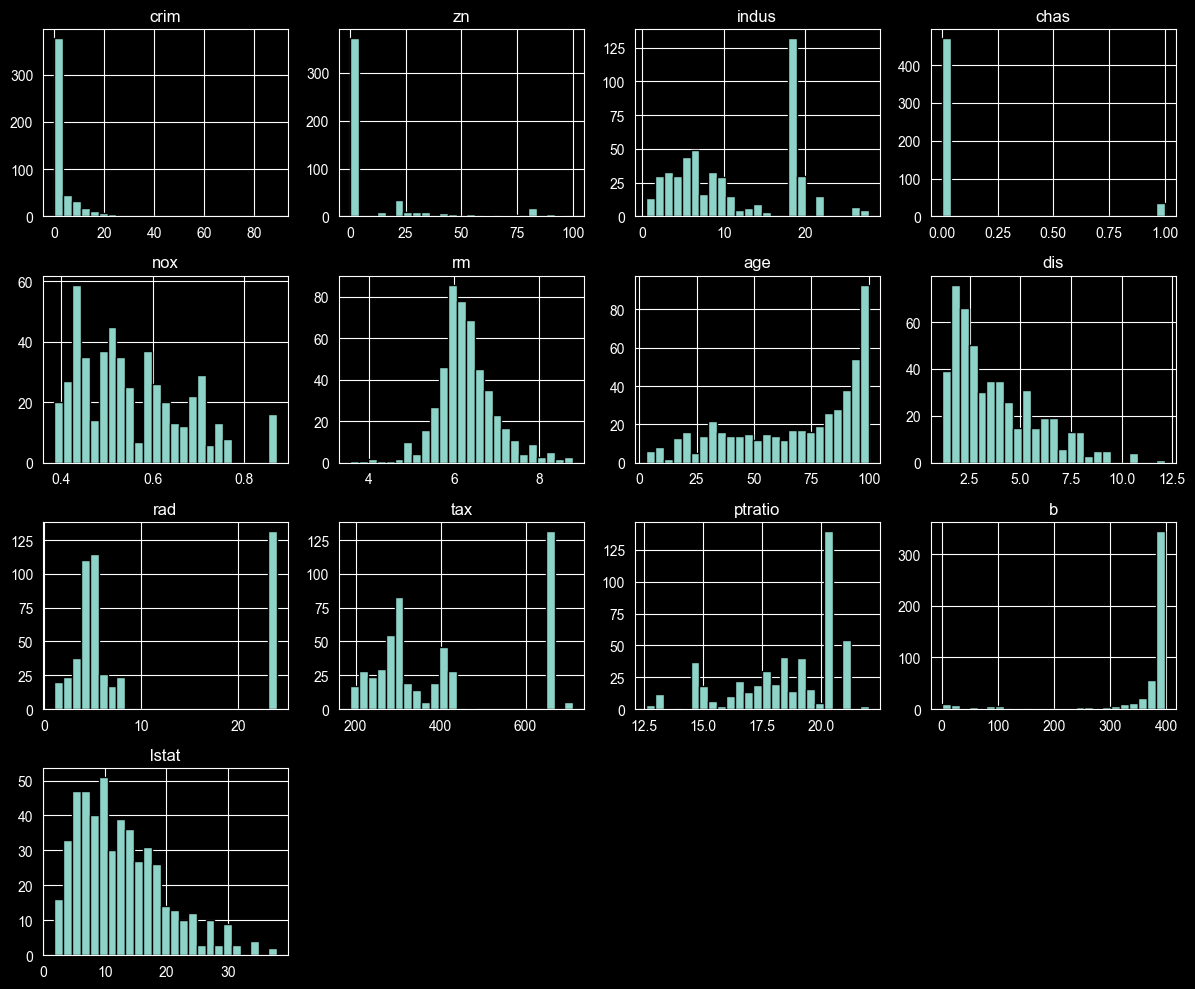

In [4]:
X.hist(figsize=(12, 10), bins=25, edgecolor='black')
plt.tight_layout()
plt.show()

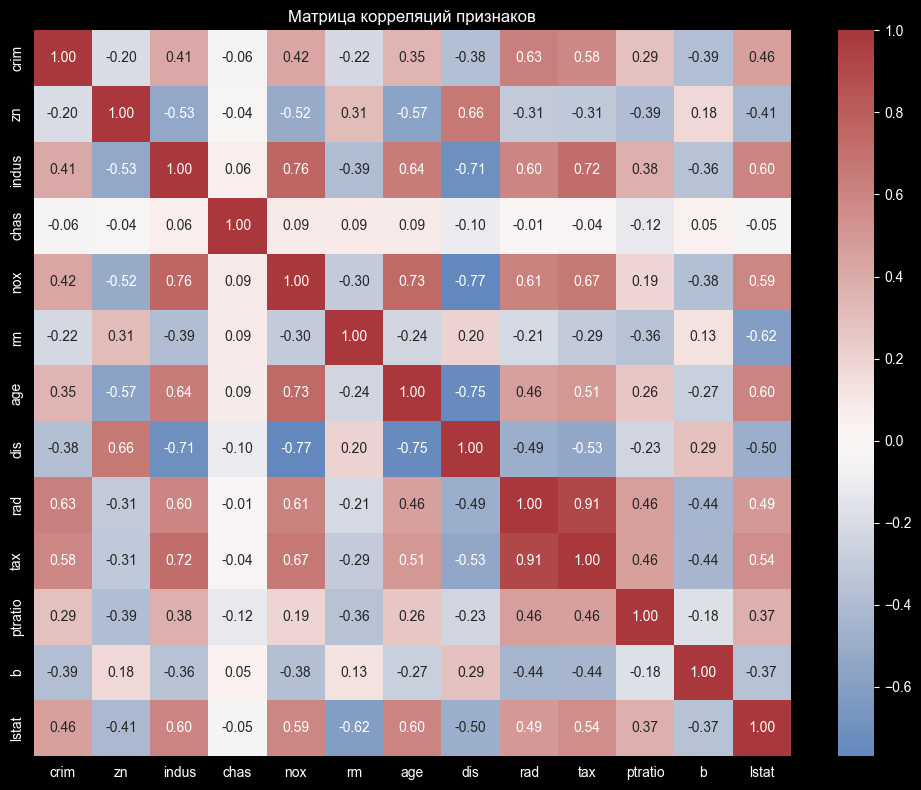

In [5]:
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

#### Ответы на вопросы:
- ***Есть ли сильно коррелированные признаки?***
Да. Анализ матрицы корреляций показал наличие нескольких пар признаков с высокой линейной связью. Примеры:
RAD и TAX (r ≈ 0.91) почти дублируют друг друга
INDUS и NOX (r ≈ 0.76) сильная связь
DIS и NOX (r ≈ −0.77) сильная обратная связь
INDUS и DIS (r ≈ −0.71) сильная обратная связь

- ***Можно ли предположить, что часть признаков содержит избыточную
информацию?***  Да, можно. Высокая корреляция между признаками свидетельствует о том, что часть переменных дублирует информацию друг друга. Например, RAD (индекс доступности к шоссе) и TAX (ставка налога на недвижимость) тесно связаны с инфраструктурной развитостью района, а INDUS (доля промышленных земель) и NOX (концентрация оксидов азота) отражают промышленную нагрузку и уровень загрязнения. Это подтверждает, что исходное 13-мерное пространство признаков содержит значительную избыточность, и его можно эффективно сжать методами снижения размерности без существенной потери полезной информации.


## Задание 2. Реализация PCA


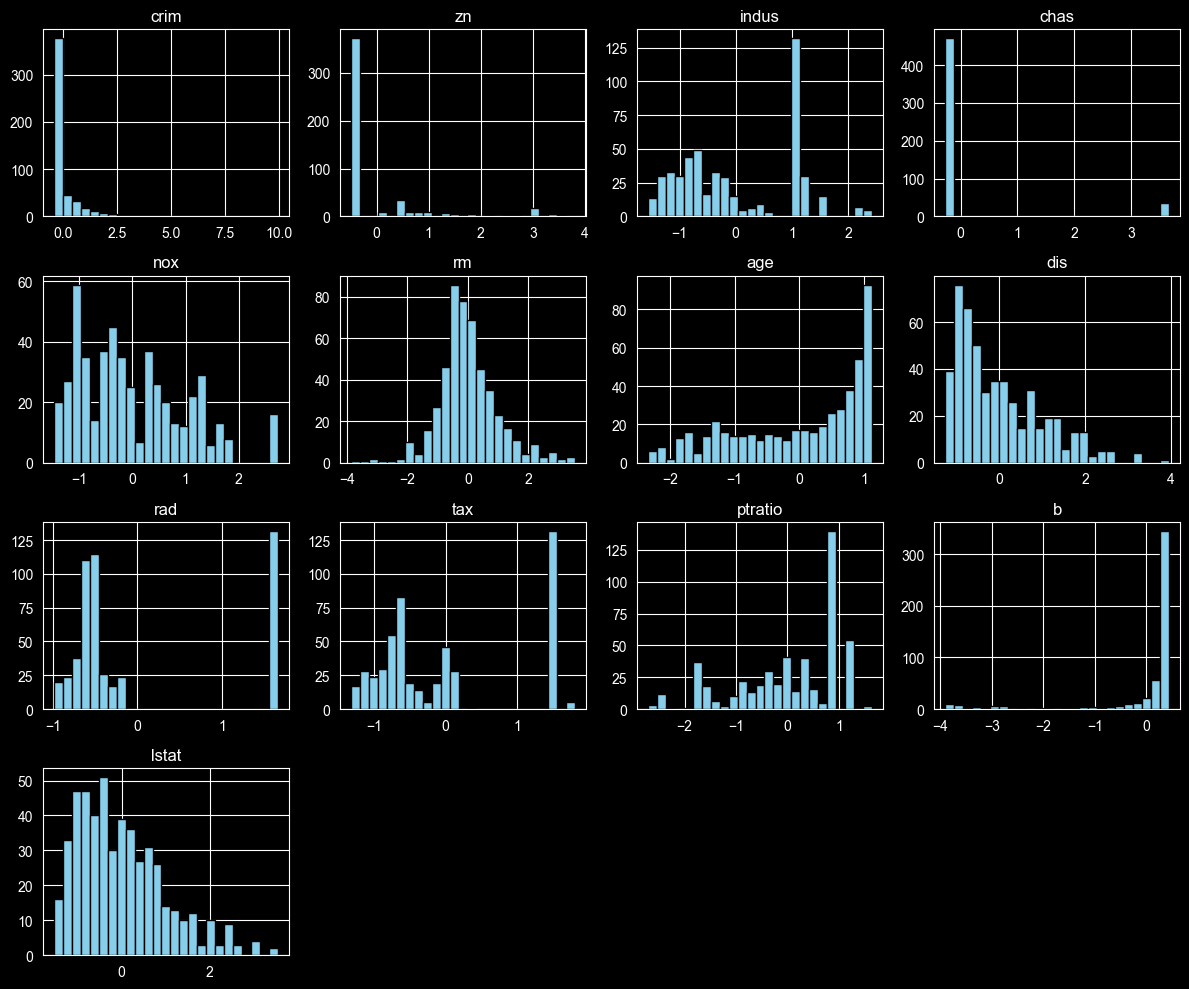

In [6]:
# 1. Стандартизация данных:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_scaled_df.hist(figsize=(12, 10), bins=25, edgecolor='black', color='skyblue')
plt.tight_layout()
plt.show()

In [7]:
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)
# 2. Вычисление ковариационной матрицы
cov_matrix = np.cov(X_scaled.T)

# 3. Нахождение собственных значений и векторов
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 4. Сортировка по убыванию собственных значений
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

# 5. Проекция на первые k компонент
k = 2
X_pca_manual = X_scaled @ eigenvectors[:, :k]

Сравнение результата с реализацией sklearn.decomposition.PCA

In [8]:
pca_sklearn = PCA()
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

is_correct = np.allclose(np.abs(X_pca_manual), np.abs(X_pca_sklearn[:, :k]), atol=1e-5)
print(f"Результат совпадает с sklearn: {is_correct}")

Результат совпадает с sklearn: True


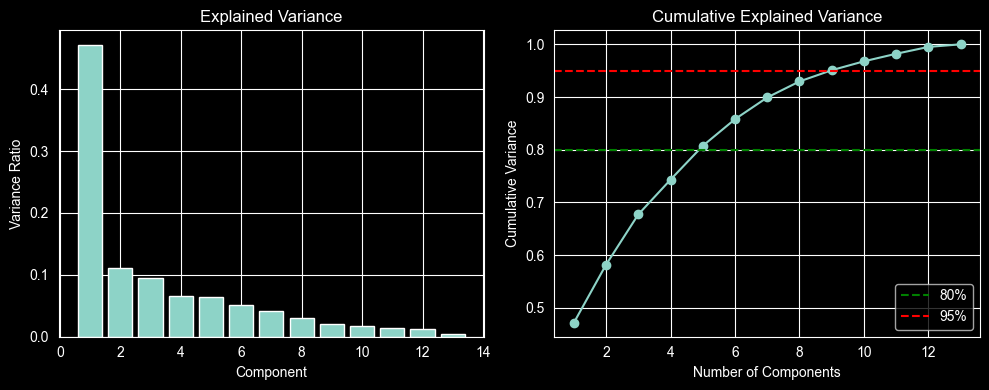

In [9]:
# Построение графика дисперсии
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio)
plt.xlabel('Component')
plt.ylabel('Variance Ratio')
plt.title('Explained Variance')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.80, color='g', linestyle='--', label='80%')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Ответы на вопросы:
1. Сколько компонент объясняют 80% дисперсии?
2. Сколько компонент объясняют 95% дисперсии?

In [10]:
print(f"Компонент для 80% дисперсии: {np.argmax(cumulative_variance >= 0.80) + 1}")
print(f"Компонент для 95% дисперсии: {np.argmax(cumulative_variance >= 0.95) + 1}")

Компонент для 80% дисперсии: 5
Компонент для 95% дисперсии: 9


## Задание 3. Интерпретация главных компонент

In [11]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)

print("Коэффициенты признаков в первых трёх компонентах:")
print(components_df.round(3))
print()

for i, col in enumerate(['PC1', 'PC2', 'PC3'], 1):
    print(f"Топ-3 признака для компоненты {i}:")
    top = components_df[col].abs().sort_values(ascending=False).head(3)
    for feat, val in top.items():
        sign = '+' if components_df.loc[feat, col] > 0 else '-'
        print(f"  {sign} {feat}: {val:.3f}")
    print()

Коэффициенты признаков в первых трёх компонентах:
           PC1    PC2    PC3
crim     0.251 -0.315  0.247
zn      -0.256 -0.323  0.298
indus    0.347  0.112 -0.017
chas     0.005  0.455  0.292
nox      0.343  0.219  0.121
rm      -0.188  0.150  0.589
age      0.314  0.312 -0.019
dis     -0.322 -0.349 -0.050
rad      0.320 -0.272  0.287
tax      0.339 -0.239  0.220
ptratio  0.205 -0.306 -0.327
b       -0.203  0.239 -0.302
lstat    0.310 -0.074 -0.267

Топ-3 признака для компоненты 1:
  + indus: 0.347
  + nox: 0.343
  + tax: 0.339

Топ-3 признака для компоненты 2:
  + chas: 0.455
  - dis: 0.349
  - zn: 0.323

Топ-3 признака для компоненты 3:
  + rm: 0.589
  - ptratio: 0.327
  - b: 0.302



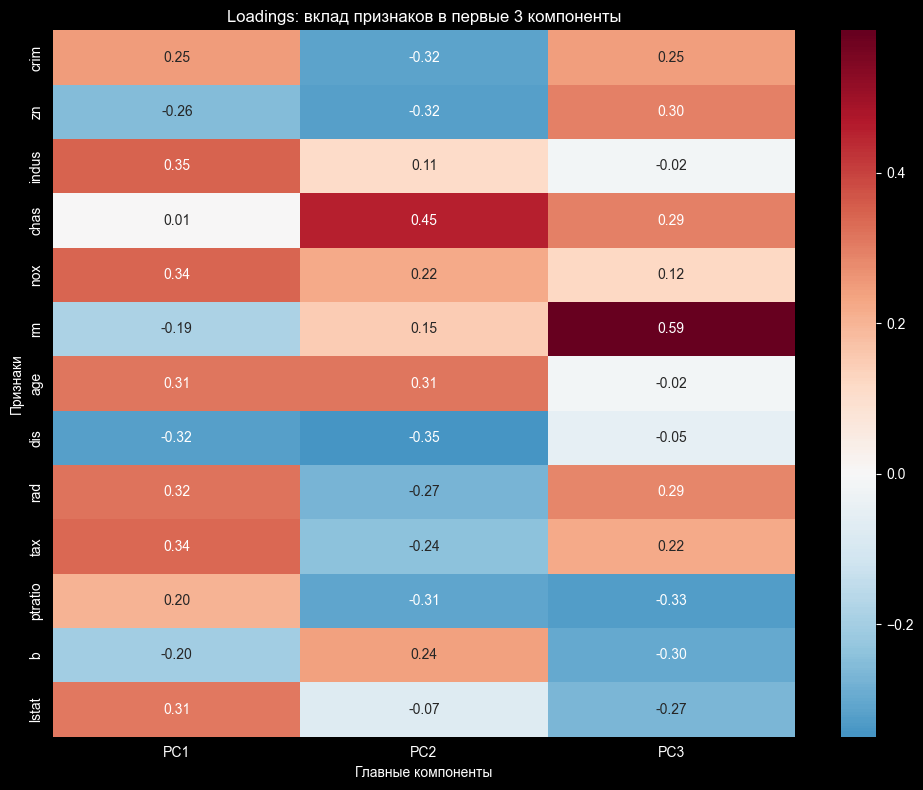

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(components_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Loadings: вклад признаков в первые 3 компоненты')
plt.ylabel('Признаки')
plt.xlabel('Главные компоненты')
plt.tight_layout()
plt.show()

In [13]:
threshold = 0.15
low_impact = components_df.abs().max(axis=1) < threshold
print(f"Признаки с малым влиянием (порог {threshold}):")
if low_impact.any():
    print(components_df[low_impact])
else:
    print("Все признаки вносят заметный вклад в хотя бы одну из первых 3 компонент")

Признаки с малым влиянием (порог 0.15):
Все признаки вносят заметный вклад в хотя бы одну из первых 3 компонент


#### Ответьте:
1. ***Какие признаки больше всего влияют на первую компоненту?***
`INDUS`, `NOX`, `TAX`
2. ***Можно ли интерпретировать первую компоненту как некоторую
комбинацию исходных признаков?***
Да, можно. Это линейная комбинация исходных признаков с весами, полученными из собственного вектора ковариационной матрицы. Позволяет интерпретировать PC1 как скрытый фактор, связанный с уровнем индустриализации/загрязнения района.
3. ***Есть ли признаки, которые практически не влияют на первые компоненты?***
Все 13 признаков имеют вклад >0.15 хотя бы в одну из первых трёх компонент. Это означает, что исходные признаки достаточно информативны и ни один признак не является полностью избыточным.

## Задание 4. Визуализация данных

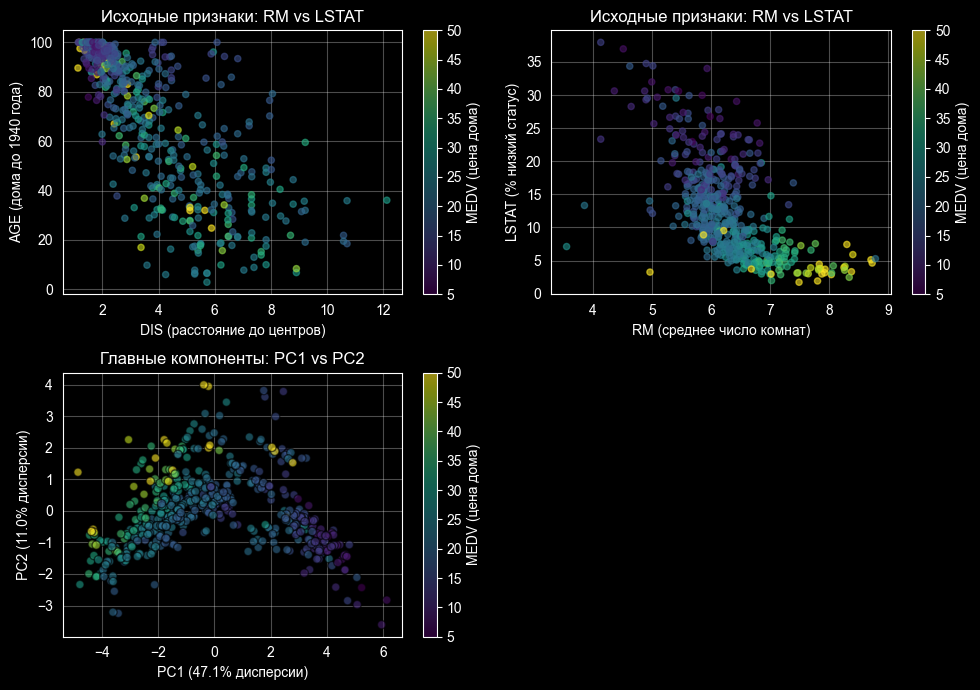

In [14]:
# 1. Визуализация по двум исходным признакам (выбираем информативные)
plt.figure(figsize=(10, 7))

plt.subplot(2, 2, 1)
plt.scatter(X['dis'], X['age'], c=df['medv'], cmap='viridis', alpha=0.6, s=20)
plt.xlabel('DIS (расстояние до центров)')
plt.ylabel('AGE (дома до 1940 года)')
plt.title('Исходные признаки: RM vs LSTAT')
plt.colorbar(label='MEDV (цена дома)')
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(X['rm'], X['lstat'], c=df['medv'], cmap='viridis', alpha=0.6, s=20)
plt.xlabel('RM (среднее число комнат)')
plt.ylabel('LSTAT (% низкий статус)')
plt.title('Исходные признаки: RM vs LSTAT')
plt.colorbar(label='MEDV (цена дома)')
plt.grid(alpha=0.3)

# 2. Визуализация по двум главным компонентам
plt.subplot(2, 2, 3)
plt.scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1],
            alpha=0.6, edgecolors='black', c=df['medv'], cmap='viridis')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% дисперсии)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% дисперсии)')
plt.title('Главные компоненты: PC1 vs PC2')
plt.colorbar(label='MEDV (цена дома)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Дополнительно: матрица рассеяния для нескольких признаков
print(f"PC1 объясняет: {pca.explained_variance_ratio_[0]*100:.1f}% дисперсии")
print(f"PC2 объясняет: {pca.explained_variance_ratio_[1]*100:.1f}% дисперсии")
print(f"Вместе: {(pca.explained_variance_ratio_.sum())*100:.1f}%")

PC1 объясняет: 47.1% дисперсии
PC2 объясняет: 11.0% дисперсии
Вместе: 67.7%


#### Ответьте:
1. Улучшилась ли визуализация после PCA?
2. Почему в пространстве главных компонент структура может быть заметнее?

## Задание 5. Нелинейные методы снижения размерности

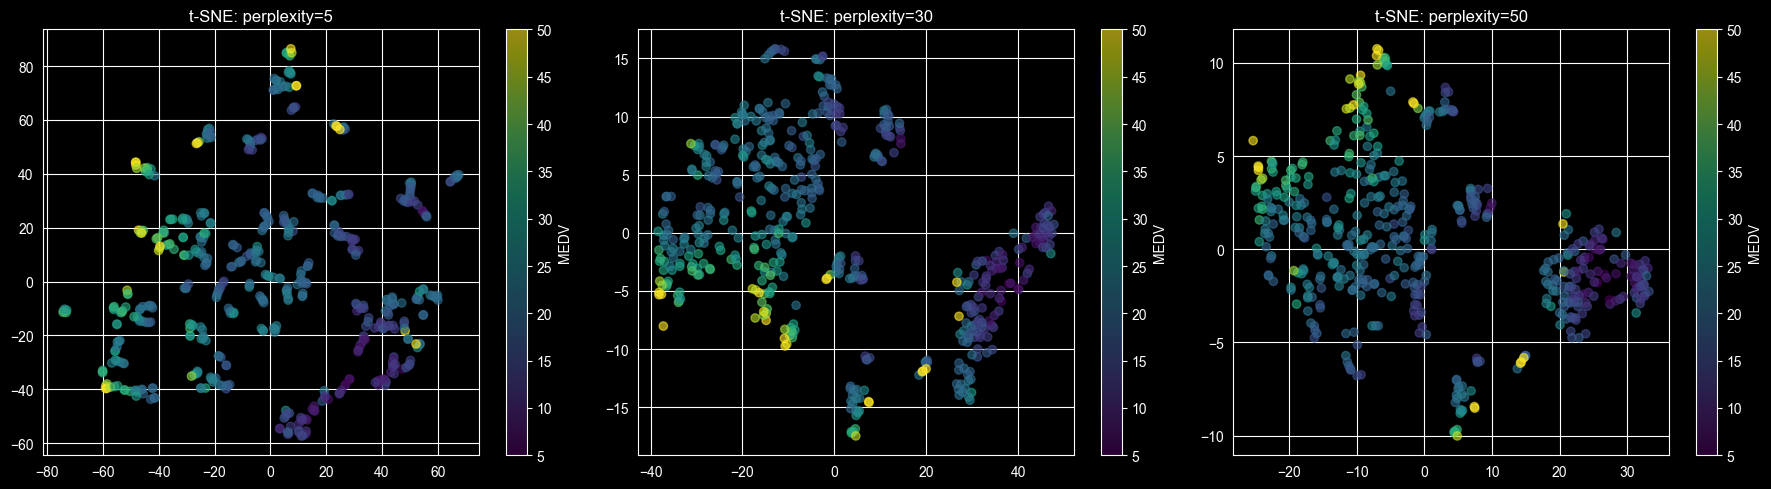

In [16]:
plt.figure(figsize=(18, 5))

# Perplexity = 5
plt.subplot(1, 3, 1)
tsne_5 = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne_5 = tsne_5.fit_transform(X_scaled)
plt.scatter(X_tsne_5[:, 0], X_tsne_5[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('t-SNE: perplexity=5')
plt.colorbar(label='MEDV')

# Perplexity = 30
plt.subplot(1, 3, 2)
tsne_30 = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_30 = tsne_30.fit_transform(X_scaled)
plt.scatter(X_tsne_30[:, 0], X_tsne_30[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('t-SNE: perplexity=30')
plt.colorbar(label='MEDV')

# Perplexity = 50
plt.subplot(1, 3, 3)
tsne_50 = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne_50 = tsne_50.fit_transform(X_scaled)
plt.scatter(X_tsne_50[:, 0], X_tsne_50[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('t-SNE: perplexity=50')
plt.colorbar(label='MEDV')

plt.tight_layout()
plt.show()

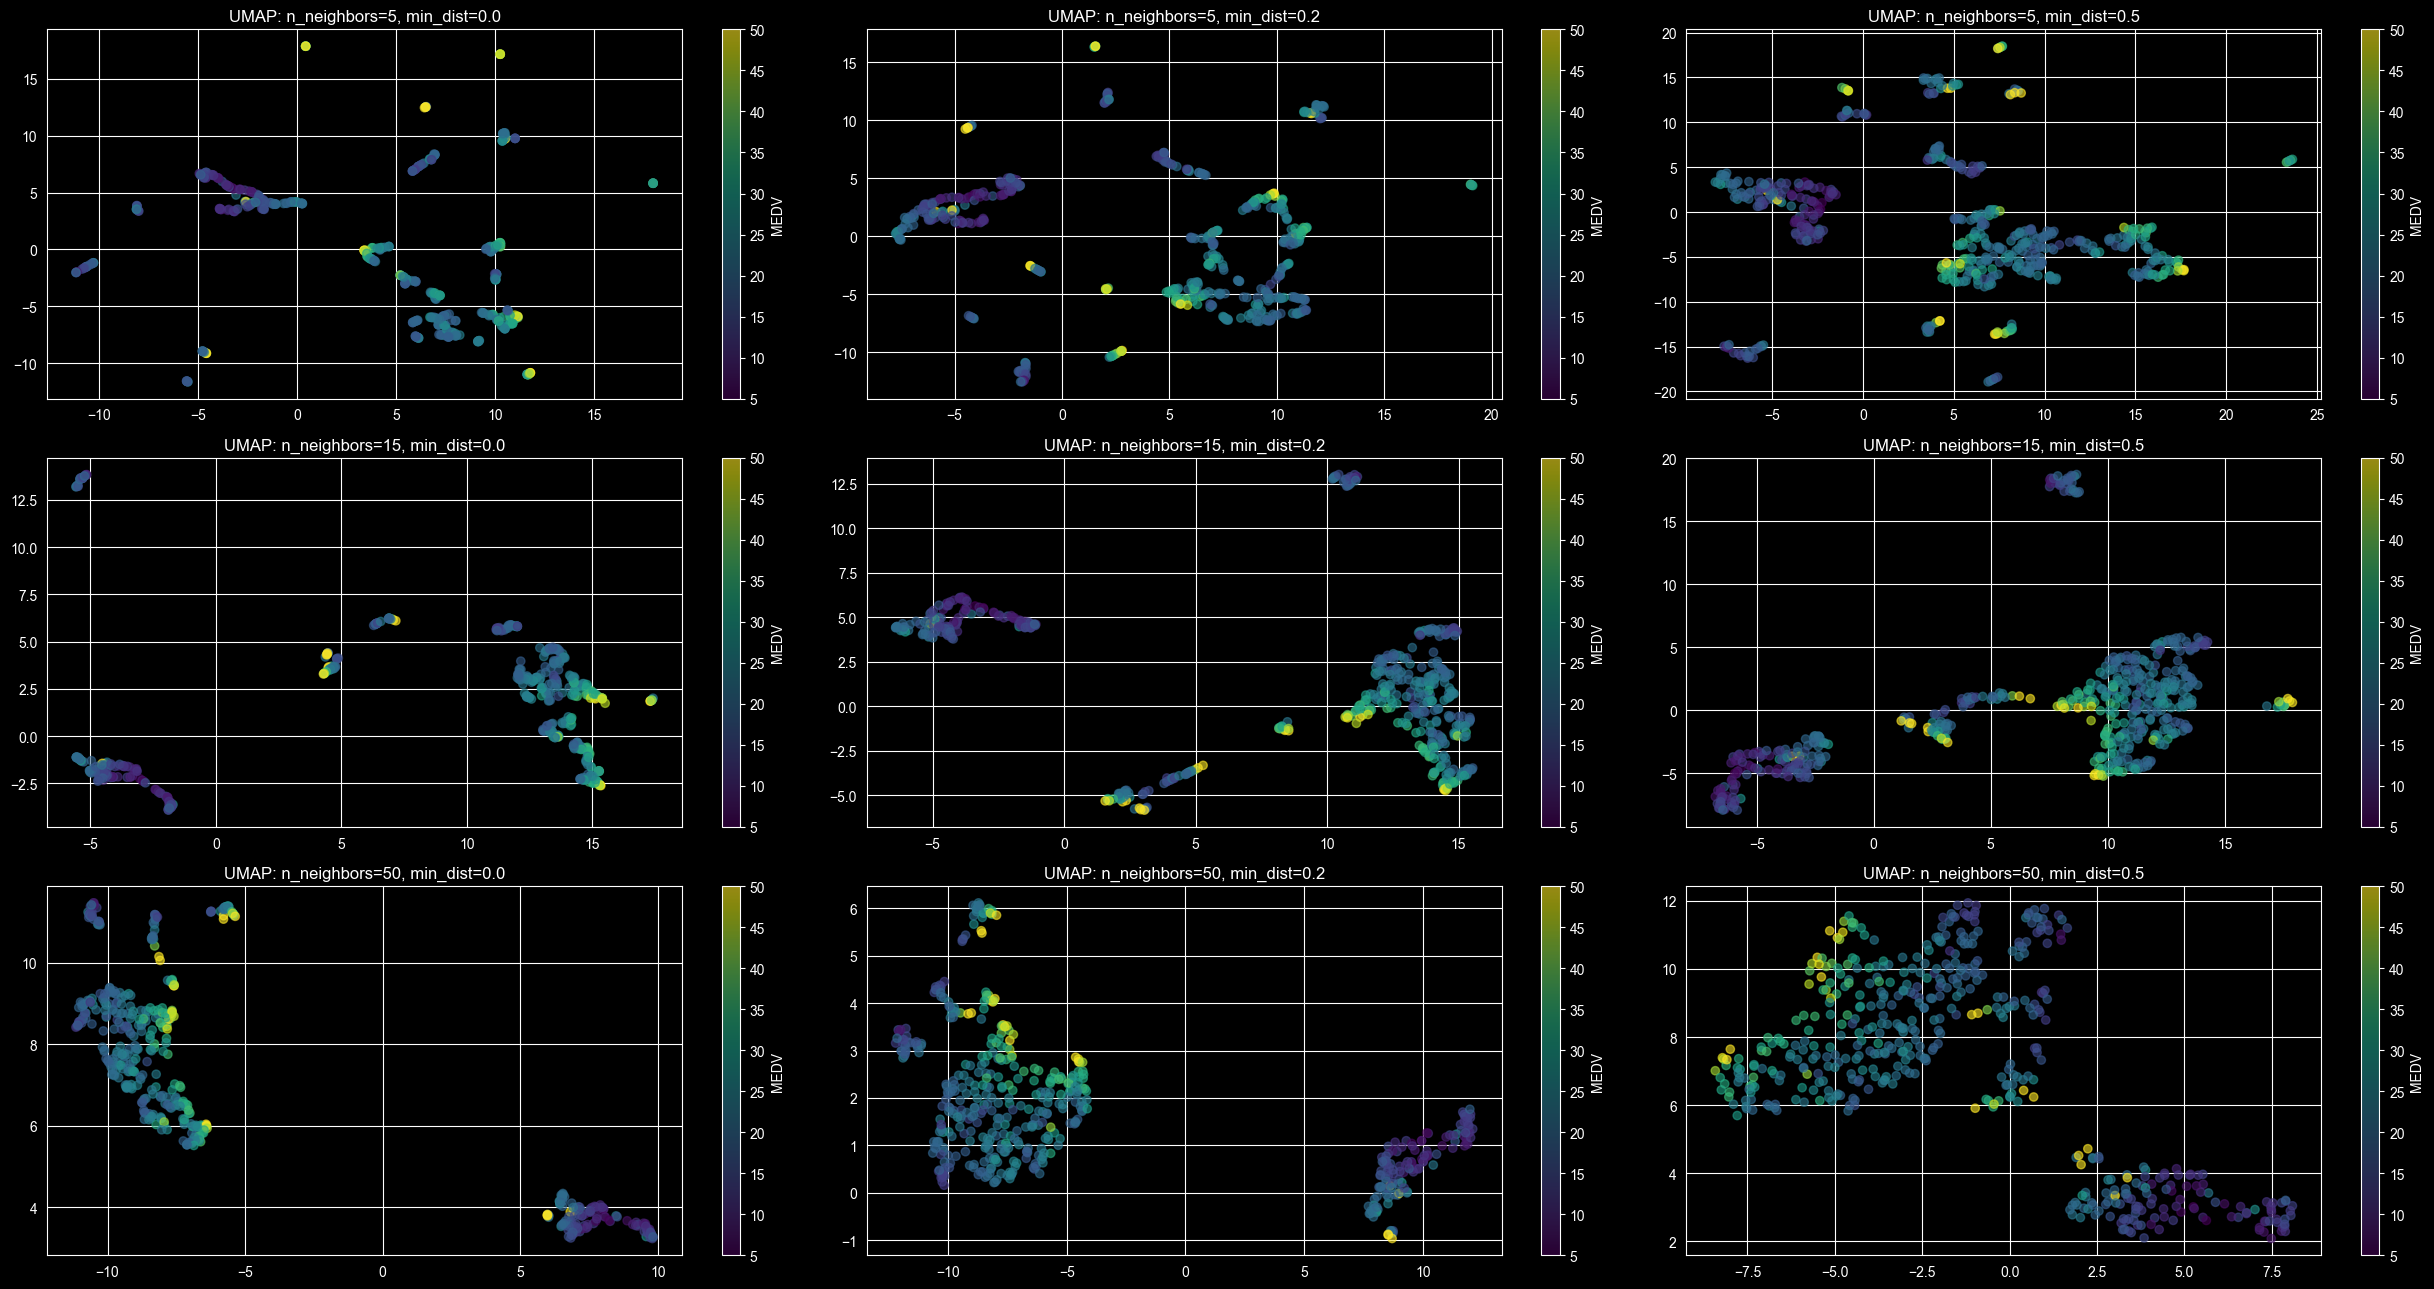

In [17]:
plt.figure(figsize=(25, 13))

# UMAP: n_neighbors=5
plt.subplot(3, 3, 1)
umap_model_11 = umap.UMAP(n_neighbors=5, min_dist=0.0, random_state=42)
X_umap_11 = umap_model_11.fit_transform(X_scaled)
plt.scatter(X_umap_11[:, 0], X_umap_11[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=5, min_dist=0.0')
plt.colorbar(label='MEDV')

plt.subplot(3, 3, 2)
umap_model_12 = umap.UMAP(n_neighbors=5, min_dist=0.2, random_state=42)
X_umap_12 = umap_model_12.fit_transform(X_scaled)
plt.scatter(X_umap_12[:, 0], X_umap_12[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=5, min_dist=0.2')
plt.colorbar(label='MEDV')

plt.subplot(3, 3, 3)
umap_model_13 = umap.UMAP(n_neighbors=5, min_dist=0.5, random_state=42)
X_umap_13 = umap_model_13.fit_transform(X_scaled)
plt.scatter(X_umap_13[:, 0], X_umap_13[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=5, min_dist=0.5')
plt.colorbar(label='MEDV')

# UMAP: n_neighbors=15
plt.subplot(3, 3, 4)
umap_model_21 = umap.UMAP(n_neighbors=15, min_dist=0.0, random_state=42)
X_umap_21 = umap_model_21.fit_transform(X_scaled)
plt.scatter(X_umap_21[:, 0], X_umap_21[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=15, min_dist=0.0')
plt.colorbar(label='MEDV')

plt.subplot(3, 3, 5)
umap_model_22 = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=42)
X_umap_22 = umap_model_22.fit_transform(X_scaled)
plt.scatter(X_umap_22[:, 0], X_umap_22[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=15, min_dist=0.2')
plt.colorbar(label='MEDV')

plt.subplot(3, 3, 6)
umap_model_23 = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=42)
X_umap_23 = umap_model_23.fit_transform(X_scaled)
plt.scatter(X_umap_23[:, 0], X_umap_23[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=15, min_dist=0.5')
plt.colorbar(label='MEDV')

# UMAP: n_neighbors=50
plt.subplot(3, 3, 7)
umap_model_31 = umap.UMAP(n_neighbors=50, min_dist=0.0, random_state=42)
X_umap_31 = umap_model_31.fit_transform(X_scaled)
plt.scatter(X_umap_31[:, 0], X_umap_31[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=50, min_dist=0.0')
plt.colorbar(label='MEDV')

plt.subplot(3, 3, 8)
umap_model_32 = umap.UMAP(n_neighbors=50, min_dist=0.2, random_state=42)
X_umap_32 = umap_model_32.fit_transform(X_scaled)
plt.scatter(X_umap_32[:, 0], X_umap_32[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=50, min_dist=0.2')
plt.colorbar(label='MEDV')

plt.subplot(3, 3, 9)
umap_model_33 = umap.UMAP(n_neighbors=50, min_dist=0.5, random_state=42)
X_umap_33 = umap_model_33.fit_transform(X_scaled)
plt.scatter(X_umap_33[:, 0], X_umap_33[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP: n_neighbors=50, min_dist=0.5')
plt.colorbar(label='MEDV')

plt.tight_layout()
plt.show()

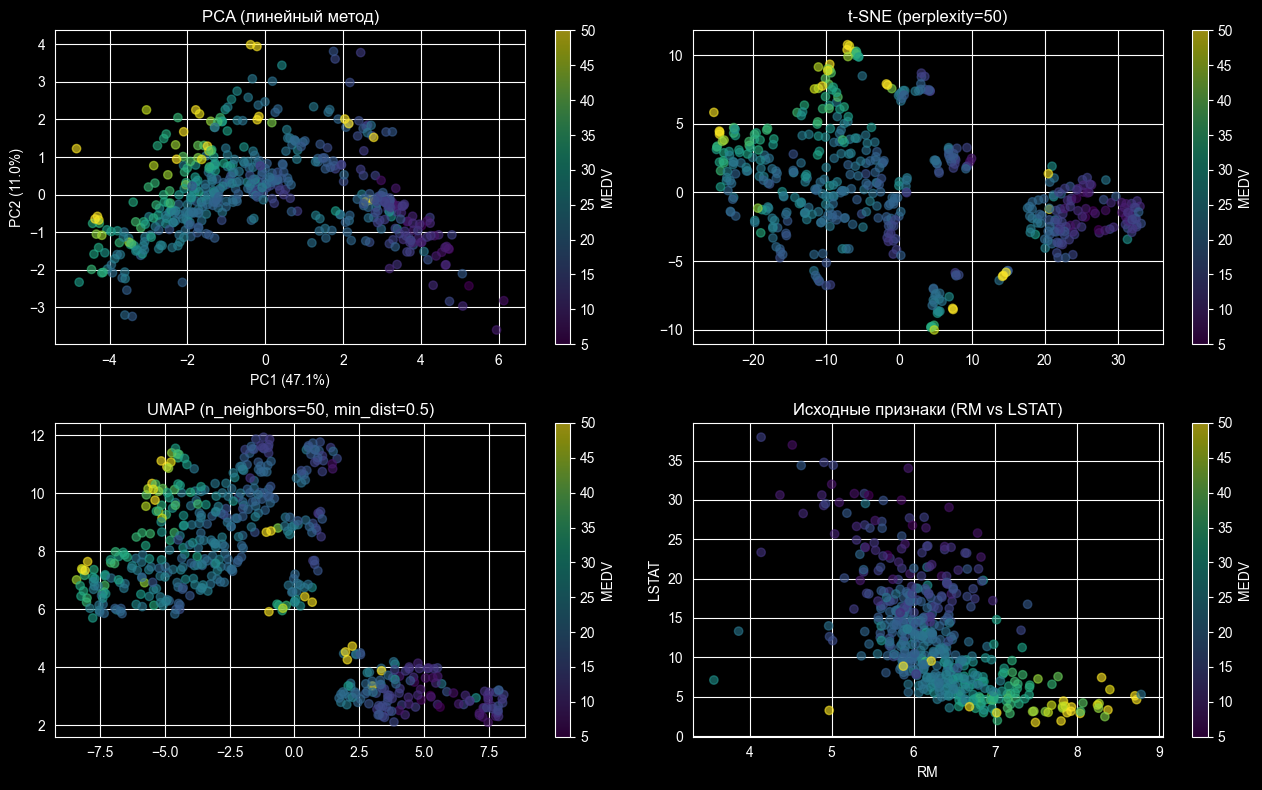

In [18]:
plt.figure(figsize=(13, 8))

# PCA
plt.subplot(2, 2, 1)
plt.scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('PCA (линейный метод)')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.colorbar(label='MEDV')

# t-SNE
plt.subplot(2, 2, 2)
plt.scatter(X_tsne_50[:, 0], X_tsne_50[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('t-SNE (perplexity=50)')
plt.colorbar(label='MEDV')

# UMAP
plt.subplot(2, 2, 3)
plt.scatter(X_umap_33[:, 0], X_umap_33[:, 1], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('UMAP (n_neighbors=50, min_dist=0.5)')
plt.colorbar(label='MEDV')

# Исходные признаки
plt.subplot(2, 2, 4)
plt.scatter(X['rm'], X['lstat'], c=df['medv'], cmap='viridis', alpha=0.6)
plt.title('Исходные признаки (RM vs LSTAT)')
plt.xlabel('RM')
plt.ylabel('LSTAT')
plt.colorbar(label='MEDV')

plt.tight_layout()
plt.show()

#### Ответьте:
1. Как меняется структура данных при разных параметрах?
2. Какой метод даёт наиболее интерпретируемую визуализацию?
3. Почему результаты разных методов могут существенно отличаться?

## Задание 6. Исследование степени сжатия данных
### 6.1-6.3

In [19]:
k_values = [2, 5, 10, 13]

results = []

print("Оценка ошибки восстановления для разных k:")
print()

for k in k_values:
    # 6.1: Снижение размерности
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_scaled)

    # 6.2: Восстановление данных (обратное преобразование)
    X_reconstructed = pca.inverse_transform(X_reduced)

    # 6.3: Оценка ошибки (MSE)
    mse = mean_squared_error(X_scaled, X_reconstructed)

    # Доля объяснённой дисперсии
    var_explained = pca.explained_variance_ratio_.sum() * 100

    results.append({
        'k': k,
        'MSE': mse,
        'Explained Variance (%)': var_explained
    })

    print(f"k={k:2d} | MSE={mse:.4f} | Объяснённая дисперсия={var_explained:.1f}%")

# Таблица результатов
results_df = pd.DataFrame(results)
print("\nИтоговая таблица:")
print(results_df.to_string(index=False))

Оценка ошибки восстановления для разных k:

k= 2 | MSE=0.4179 | Объяснённая дисперсия=58.2%
k= 5 | MSE=0.1925 | Объяснённая дисперсия=80.7%
k=10 | MSE=0.0322 | Объяснённая дисперсия=96.8%
k=13 | MSE=0.0000 | Объяснённая дисперсия=100.0%

Итоговая таблица:
 k          MSE  Explained Variance (%)
 2 4.178596e-01               58.182250
 5 1.925053e-01               80.734828
10 3.219894e-02               96.777657
13 1.055243e-30              100.000000


### 6.4 Визуальный анализ

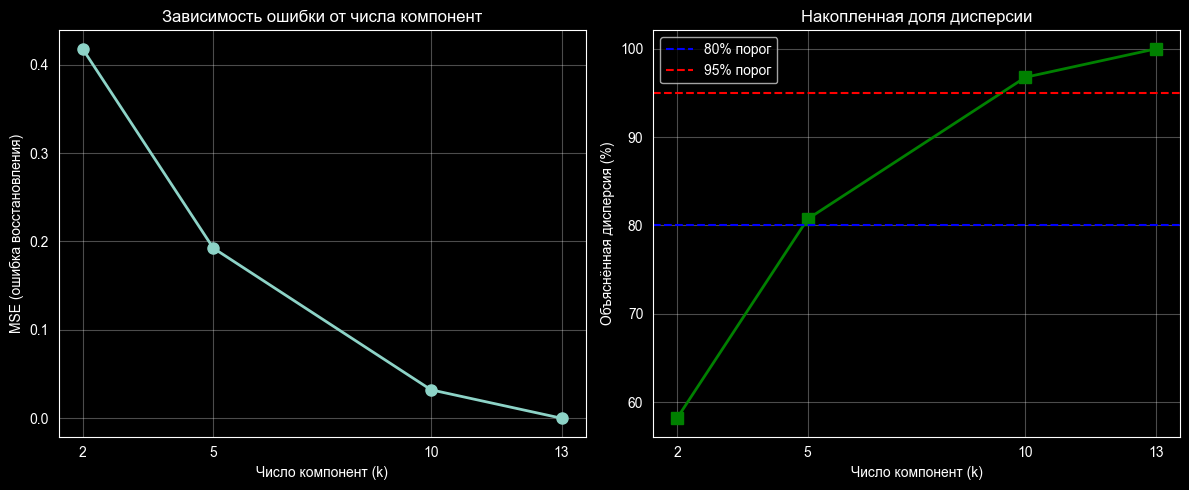

In [20]:
plt.figure(figsize=(12, 5))

# График 1: Зависимость MSE от k
plt.subplot(1, 2, 1)
plt.plot(results_df['k'], results_df['MSE'], marker='o', linewidth=2, markersize=8)
plt.xlabel('Число компонент (k)')
plt.ylabel('MSE (ошибка восстановления)')
plt.title('Зависимость ошибки от числа компонент')
plt.grid(True, alpha=0.3)
plt.xticks(results_df['k'])

# График 2: Накопленная объяснённая дисперсия
plt.subplot(1, 2, 2)
plt.plot(results_df['k'], results_df['Explained Variance (%)'],
         marker='s', color='green', linewidth=2, markersize=8)
plt.axhline(y=80, color='blue', linestyle='--', label='80% порог')
plt.axhline(y=95, color='red', linestyle='--', label='95% порог')
plt.xlabel('Число компонент (k)')
plt.ylabel('Объяснённая дисперсия (%)')
plt.title('Накопленная доля дисперсии')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(results_df['k'])

plt.tight_layout()
plt.show()

### 6.5 Интерпретация результатов
#### Ответьте на следующие вопросы:
##### **_1. Почему при малом числе компонент ошибка восстановления большая?_**
При проецировании 13-мерных данных на очень низкоразмерное пространство большая часть информации (вариаций признаков) «отсекается», так как сохраняются только направления с максимальной дисперсией. Чем меньше компонент, тем больше деталей теряется, следовательно, ошибка (MSE) растёт.
##### **_2. Почему увеличение числа компонент уменьшает ошибку?_**
Каждая новая главная компонента добавляет информацию о следующем по величине направлении дисперсии. Чем больше компонент сохраняем, тем полнее описываем исходное пространство, а значит реконструкция точнее, следовательно, MSE уменьшается.
##### **_3. Можно ли полностью восстановить исходные данные при использовании всех компонент?_**
Да. Если взять k = 13, PCA становится обратимым преобразованием. Ошибка восстановления будет практически нулевой, с учётом только машинной погрешности.
##### **_4. Как это связано с объяснённой дисперсией PCA?_**
Объяснённая дисперсия это какая доля информации сохранена в выбранных компонентах, а ошибка восстановления - оставшаяся дисперсия, которую мы отбросили.
##### **_5. Как можно определить разумное число компонент, при котором данные уже хорошо описаны, но размерность существенно меньше?_**
- Выбрать минимальное k, при котором накопленная дисперсия ≥ 80–95%
- На графике «дисперсия от k» найти точку, после которой прирост дисперсии резко замедляется.

## Задание 7. Итоговый анализ

#### Ответьте на следующие вопросы:
##### **_1. Какую роль играет снижение размерности в анализе данных?_**
* Уменьшает шум и избыточность признаков
* Упрощает визуализацию многомерных данных
* Помогает бороться с проклятием размерности
* Выявляет скрытые закономерности
##### **_2. Всегда ли уменьшение размерности полезно?_**
Нет, не всегда, например:
* При потере интерпретируемости признаков
* Если исходных признаков мало и они информативны
* При нелинейных зависимостях, если используются линейные методы
* Если важна точная реконструкция исходных данных
##### **_3. В каких случаях линейные методы могут работать хуже нелинейных?_**
* Данные имеют сложную нелинейную структуру (спирали, кольца, кластеры сложной формы)
* Признаки связаны нелинейными зависимостями
* Нужно сохранить локальные расстояния между точками
##### **_4. Какие преимущества и ограничения есть у методов PCA, t-SNE и UMAP?_**
**PCA <br>
Преимущества:**<br>
Быстрый, интерпретируемый, сохраняет глобальную структуру, обратимое преобразование<br>
**Ограничения:**<br>
Только линейные зависимости, плохо для визуализации сложных структур

**t-SNE<br>
Преимущества:**<br>
Отлично визуализирует кластеры, сохраняет локальные расстояния<br>
**Ограничения:**<br>
Медленный, не сохраняет глобальную структуру, чувствителен к perplexity, нет обратного преобразования

**UMAP<br>
Преимущества:**<br>
Быстрее t-SNE, сохраняет и локальную, и глобальную структуру, масштабируемый<br>
**Ограничения:**<br>
Сложнее в интерпретации, больше гиперпараметров для настройки